# Victory Status in Chess

Chess is a game that humans have been playing for over 1400 years. Today, the game is often played virtually through applications like chess.com or lichess.org. Due to the popularity of these sites, thousands of games may be played each day and the amount of data collected from all games is massive and extensive.

The Elo system is a ranking system to assign a numerical value to the chess skill of any given player. The original purpose of this system is to be able to determine the odds that a player will win over their opponent. Upon winning, a player’s Elo rating goes up, and the opposite is true upon losing. The amount these values change depends on the discrepancy between the two ratings.

There are a few ways for a chess match to end. A player could checkmate their opponent (win), the match could end in a stalemate (draw), the time clock could run out on the opponents clock (win), or they could resign (win). 


# Predictive Question

In this project, we will develop a model to predict the victory status of any game based on the rating associated with each player and the color of each player in a chess match: draw, resign, clock, or mate.

In [35]:
# Run this code first
library(repr)
library(tidyverse)
library(tidymodels)

In [42]:
chess <- read_csv("games.csv") %>%
select(victory_status, turns, winner, white_rating, black_rating, rated)

chess_victory_status <- chess %>%
group_by(victory_status, winner) %>%
summarize(n=n())

Parsed with column specification:
cols(
  id = col_character(),
  rated = col_logical(),
  created_at = col_double(),
  last_move_at = col_double(),
  turns = col_double(),
  victory_status = col_character(),
  winner = col_character(),
  increment_code = col_character(),
  white_id = col_character(),
  white_rating = col_double(),
  black_id = col_character(),
  black_rating = col_double(),
  moves = col_character(),
  opening_eco = col_character(),
  opening_name = col_character(),
  opening_ply = col_double()
)

`summarise()` regrouping output by 'victory_status' (override with `.groups` argument)



This is a visualization of the breakdown of all games and how they end.

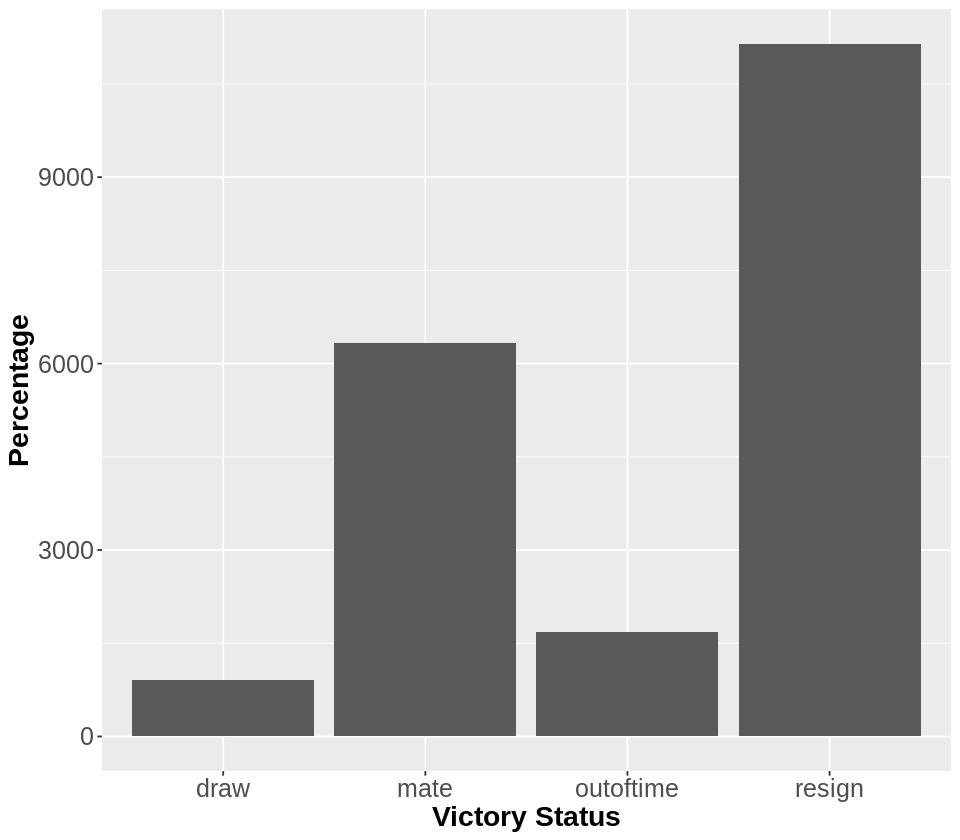

In [50]:
options(repr.plot.width = 10, repr.plot.width = 8)

chess_victory_status_plot <- chess_victory_status %>%
ggplot(aes(x = victory_status, y = n)) +
geom_bar(stat = "identity") +
labs(x = "Victory Status", y = "Percentage") +
theme(axis.text=element_text(size=15),
     axis.title=element_text(size=17,face="bold"))

chess_victory_status_plot